# LLM interactions

Install packages

In [1]:
#%pip install matplotlib                # Python library for creating visualizations
#%pip install advertools                # Tool to analyse online marketing / social media posts - Used here to count emojis

Load dataset

In [1]:
import pandas as pd
df = pd.read_csv("LLM_file_WithInfoCoded.csv", sep = ';')
display(df)

,Unnamed: 0,id,LLM,# of task,# of query,query,LLM response,LLM response - plain,Clarified own role,Defined role for LLM,Pictures/graphs shown in results,LLM provided code,Participant aborted search,query word count,LLM response word count,emoji in query,emoji in LLM response,Leslie in query,query noun count,query noun ratio
0,0,11,2,1,1,data to train llms with,Large Language Models (LLMs) require vast amou...,Large Language Models (LLMs) require vast amou...,N,N,NaN,NaN,NaN,5,254,0,0,False,2,0.400000
1,1,11,2,1,2,do you have actual datasets?,I apologize for the confusion in my previous r...,I apologize for the confusion in my previous r...,N,N,NaN,NaN,NaN,5,193,0,0,False,1,0.200000
2,2,11,2,1,3,Where can I find open-source datasets for LLM ...,There are several open-source datasets availab...,There are several open-source datasets availab...,N,N,NaN,NaN,NaN,9,275,0,0,False,2,0.222222
3,3,11,2,1,4,give me a link to,"I apologize, but I cannot provide a direct lin...","I apologize, but I cannot provide a direct lin...",N,N,NaN,NaN,NaN,5,174,0,0,False,1,0.200000
4,4,11,2,1,5,give me a link to The Pile,"I apologize, but I cannot provide direct links...","I apologize, but I cannot provide direct links...",N,N,NaN,NaN,NaN,7,130,0,0,False,2,0.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,291,44,2,2,6,How did the Ordonnance de la Marine influence ...,"The Ordonnance de la Marine, issued by Louis X...","The Ordonnance de la Marine, issued by Louis X...",N,NaN,NaN,NaN,NaN,13,297,0,0,False,5,0.384615
292,292,45,2,1,1,find me datasets that can answer the question ...,Several datasets from recent studies can help ...,Several datasets from recent studies can help ...,N,N,NaN,NaN,NaN,18,274,0,0,False,9,0.500000
293,293,45,2,2,prompt,"For the following chat, I want you to act as t...","Certainly! I'll be happy to act as Leslie, you...","Certainly! I'll be happy to act as Leslie, you...",NaN,NaN,NaN,NaN,NaN,63,52,0,0,True,15,0.238095
294,294,45,2,2,1,You know that I'm always wondering why it is m...,Hey there! I totally get why you're curious ab...,Hey there! I totally get why you're curious ab...,N,NaN,NaN,NaN,NaN,37,334,0,0,False,7,0.189189


In [2]:
# Define samples
df = df[df['# of query'] != 'prompt']           # Excludes prompts from analyses
task1 = df[df['# of task'] == 1]
task2 = df[df['# of task'] == 2]

## Which emojis were used how often?

+++++ Table 6 +++++

In [4]:
import advertools as adv


# Convert column into string
s_all = df['LLM response'].str.cat(sep=' ')
# Extract emojis
emoji_summary = adv.extract_emoji(s_all)
# Create list of emojis and their counts
l = emoji_summary["top_emoji"]
print(l)
l_t = emoji_summary["top_emoji_text"]
print(l_t)
length_l = len(l)
print(length_l)


# Task 1
s_1 = task1['LLM response'].str.cat(sep=' ')
emoji_summary = adv.extract_emoji(s_1)
m = emoji_summary["top_emoji"]
print(m)
m_t = emoji_summary["top_emoji_text"]
print(m_t)
length_m = len(m)
print(length_m)


# Task 2
s_2 = task2['LLM response'].str.cat(sep=' ')
emoji_summary = adv.extract_emoji(s_2)
n = emoji_summary["top_emoji"]
print(n)
n_t = emoji_summary["top_emoji_text"]
print(n_t)
length_n = len(n)
print(length_n)


[('📄', 75), ('🔗', 64), ('🚀', 51), ('📌', 44), ('✅', 19), ('📊', 16), ('🔍', 12), ('📎', 11), ('📍', 11), ('📺', 11), ('😊', 9), ('🔹', 8), ('📑', 5), ('❌', 4), ('📜', 4), ('🌍', 2), ('🔟', 2), ('💡', 2), ('🛠', 2), ('📖', 2), ('👉', 2), ('📢', 1), ('❓', 1), ('📝', 1), ('🧪', 1), ('🚨', 1), ('⚠', 1), ('💾', 1), ('📂', 1), ('📈', 1), ('📚', 1), ('📘', 1), ('🌏', 1), ('🗺', 1), ('🌟', 1)]
[('page facing up', 75), ('link', 64), ('rocket', 51), ('pushpin', 44), ('check mark button', 19), ('bar chart', 16), ('magnifying glass tilted left', 12), ('paperclip', 11), ('round pushpin', 11), ('television', 11), ('smiling face with smiling eyes', 9), ('small blue diamond', 8), ('bookmark tabs', 5), ('cross mark', 4), ('scroll', 4), ('globe showing Europe-Africa', 2), ('keycap: 10', 2), ('light bulb', 2), ('hammer and wrench', 2), ('open book', 2), ('backhand index pointing right', 2), ('loudspeaker', 1), ('red question mark', 1), ('memo', 1), ('test tube', 1), ('police car light', 1), ('warning', 1), ('floppy disk', 1), ('ope

## Graph for query length

+++++ Figure 1 +++++

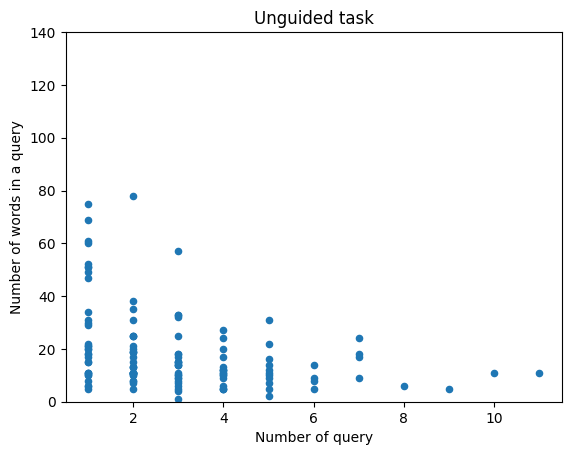

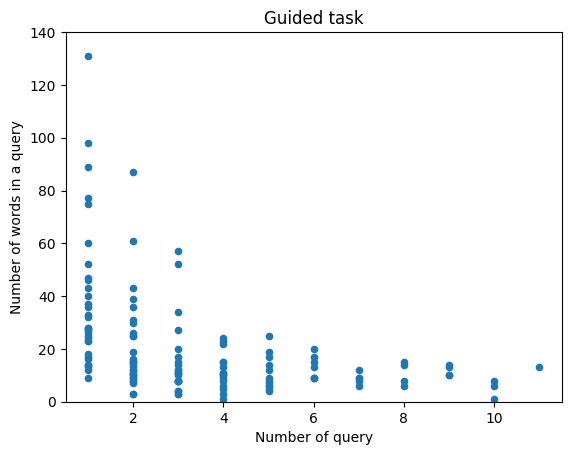

In [8]:
import matplotlib.pyplot as plt

df_t1 = task1[['id', '# of query', 'query word count']]
df_t1 = df_t1.astype({"# of query": 'int'})
df_t1 = df_t1.sort_values(by='# of query')
df_t1.set_index('id', inplace=True)

df_t1.plot(kind = 'scatter', x = '# of query', y = 'query word count')
plt.title("Unguided task")
plt.xlabel('Number of query')
plt.ylabel('Number of words in a query')
plt.ylim(0, 140)
#plt.show()
plt.savefig("SessionLength_UnguidedTask.jpg")

df_t2 = task2[['id', '# of query', 'query word count']]
df_t2 = df_t2.astype({"# of query": 'int'})
df_t2 = df_t2.sort_values(by='# of query')
df_t2.set_index('id', inplace=True)

df_t2.plot(kind = 'scatter', x = '# of query', y = 'query word count')
plt.title("Guided task")
plt.xlabel('Number of query')
plt.ylabel('Number of words in a query')
plt.ylim(0, 140)
#plt.show()
plt.savefig("SessionLength_GuidedTask.jpg")